In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv("sri_lanka_land_prices.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20000, 11)


,District,Village,Published_Date,Price_Per_Perch,Perches,Total_Price,Road_Access,Electricity,Water,Distance_To_Town_km,Land_Type
0,Matale,Town,7/2/2020,56000,65,3640000,No,Available,Not Available,1.1,Mixed
1,Kandy,Peradeniya,4/2/2024,507000,70,35490000,Yes,Available,Not Available,11.7,Mixed
2,Kandy,Peradeniya,8/17/2020,381000,73,27813000,No,Not Available,Not Available,11.1,Agricultural
3,Matara,Deniyaya,3/28/2022,232000,50,11600000,No,Available,Available,13.6,Mixed
4,Polonnaruwa,Medirigiriya,11/3/2024,144000,26,3744000,Yes,Not Available,Not Available,17.4,Mixed


In [3]:
df = df.drop(columns=["Village", "Published_Date", "Perches", "Total_Price"])

print("Dataset shape after dropping columns:", df.shape)
df.head()

Dataset shape after dropping columns: (20000, 7)


,District,Price_Per_Perch,Road_Access,Electricity,Water,Distance_To_Town_km,Land_Type
0,Matale,56000,No,Available,Not Available,1.1,Mixed
1,Kandy,507000,Yes,Available,Not Available,11.7,Mixed
2,Kandy,381000,No,Not Available,Not Available,11.1,Agricultural
3,Matara,232000,No,Available,Available,13.6,Mixed
4,Polonnaruwa,144000,Yes,Not Available,Not Available,17.4,Mixed


In [4]:
X = df.drop("Price_Per_Perch", axis=1)
y = df["Price_Per_Perch"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (16000, 6)
Test shape : (4000, 6)


In [5]:
label_map = {
    "Yes": 1,
    "No": 0,
    "Available": 1,
    "Not Available": 0
}

binary_cols = ["Road_Access", "Electricity", "Water"]

for col in binary_cols:
    X_train[col] = X_train[col].map(label_map)
    X_test[col] = X_test[col].map(label_map)

for col in binary_cols:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

X_train.head()

,District,Road_Access,Electricity,Water,Distance_To_Town_km,Land_Type
5894,Kandy,0,1,0,13.0,Commercial
3728,Colombo,0,0,1,11.6,Residential
8958,Matale,0,0,0,2.7,Agricultural
7671,Kilinochchi,1,0,1,1.3,Residential
5999,Kegalle,0,0,0,2.5,Mixed


In [6]:
district_mean = pd.DataFrame({
    "District": X_train["District"],
    "Price_Per_Perch": y_train
}).groupby("District")["Price_Per_Perch"].mean()

landtype_mean = pd.DataFrame({
    "Land_Type": X_train["Land_Type"],
    "Price_Per_Perch": y_train
}).groupby("Land_Type")["Price_Per_Perch"].mean()

global_price_mean = y_train.mean()

X_train["District_Mean"] = X_train["District"].map(district_mean)
X_test["District_Mean"] = X_test["District"].map(district_mean).fillna(global_price_mean)

X_train["Land_Type_Mean"] = X_train["Land_Type"].map(landtype_mean)
X_test["Land_Type_Mean"] = X_test["Land_Type"].map(landtype_mean).fillna(global_price_mean)

X_train.head()

,District,Road_Access,Electricity,Water,Distance_To_Town_km,Land_Type,District_Mean,Land_Type_Mean
5894,Kandy,0,1,0,13.0,Commercial,394663.398693,200776.423775
3728,Colombo,0,0,1,11.6,Residential,790775.757576,200280.241935
8958,Matale,0,0,0,2.7,Agricultural,124524.767802,204718.181818
7671,Kilinochchi,1,0,1,1.3,Residential,123939.117199,200280.241935
5999,Kegalle,0,0,0,2.5,Mixed,125443.365696,201690.446803


In [7]:
X_train = X_train.drop(columns=["District", "Land_Type"])
X_test = X_test.drop(columns=["District", "Land_Type"])

X_train.head()

,Road_Access,Electricity,Water,Distance_To_Town_km,District_Mean,Land_Type_Mean
5894,0,1,0,13.0,394663.398693,200776.423775
3728,0,0,1,11.6,790775.757576,200280.241935
8958,0,0,0,2.7,124524.767802,204718.181818
7671,1,0,1,1.3,123939.117199,200280.241935
5999,0,0,0,2.5,125443.365696,201690.446803


In [8]:
train_data = X_train.copy()
train_data["Price_Per_Perch"] = y_train.values

test_data = X_test.copy()
test_data["Price_Per_Perch"] = y_test.values

train_data.head()

,Road_Access,Electricity,Water,Distance_To_Town_km,District_Mean,Land_Type_Mean,Price_Per_Perch
5894,0,1,0,13.0,394663.398693,200776.423775,399000
3728,0,0,1,11.6,790775.757576,200280.241935,512000
8958,0,0,0,2.7,124524.767802,204718.181818,99000
7671,1,0,1,1.3,123939.117199,200280.241935,158000
5999,0,0,0,2.5,125443.365696,201690.446803,192000


In [9]:
train_data["Price_Ratio_To_District"] = (
    train_data["Price_Per_Perch"] / (train_data["District_Mean"] + 1e-6)
)

test_data["Price_Ratio_To_District"] = (
    test_data["Price_Per_Perch"] / (test_data["District_Mean"] + 1e-6)
)

train_data.head()

,Road_Access,Electricity,Water,Distance_To_Town_km,District_Mean,Land_Type_Mean,Price_Per_Perch,Price_Ratio_To_District
5894,0,1,0,13.0,394663.398693,200776.423775,399000,1.010988
3728,0,0,1,11.6,790775.757576,200280.241935,512000,0.647465
8958,0,0,0,2.7,124524.767802,204718.181818,99000,0.795023
7671,1,0,1,1.3,123939.117199,200280.241935,158000,1.274819
5999,0,0,0,2.5,125443.365696,201690.446803,192000,1.530571


In [10]:
columns_to_scale = [
    "Distance_To_Town_km",
    "District_Mean",
    "Land_Type_Mean",
    "Price_Per_Perch",
    "Price_Ratio_To_District"
]

scaler = RobustScaler()

train_data[columns_to_scale] = scaler.fit_transform(train_data[columns_to_scale])
test_data[columns_to_scale] = scaler.transform(test_data[columns_to_scale])

train_data.head()

,Road_Access,Electricity,Water,Distance_To_Town_km,District_Mean,Land_Type_Mean,Price_Per_Perch,Price_Ratio_To_District
5894,0,1,0,1.041237,3.908472,-1.000000,2.546392,0.017095
3728,0,0,1,0.896907,9.717625,-1.542855,3.711340,-0.639264
8958,0,0,0,-0.020619,-0.053224,3.312537,-0.546392,-0.372842
7671,1,0,1,-0.164948,-0.061812,-1.542855,0.061856,0.493456
5999,0,0,0,-0.041237,-0.039752,0.000000,0.412371,0.955229


In [11]:
iso_model = IsolationForest(
    n_estimators=400,
    contamination=0.10,
    max_samples="auto",
    random_state=42
)

iso_model.fit(train_data)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [12]:
predictions = iso_model.predict(test_data)      # 1 = normal, -1 = anomaly
scores = iso_model.decision_function(test_data) # lower score = more abnormal

results = test_data.copy()
results["Anomaly"] = predictions
results["Anomaly_Score"] = scores

results.head()

,Road_Access,Electricity,Water,Distance_To_Town_km,District_Mean,Land_Type_Mean,Price_Per_Perch,Price_Ratio_To_District,Anomaly,Anomaly_Score
10650,1,1,0,0.773196,2.911698,-1.542855,0.793814,-0.542681,1,0.039644
2041,0,0,1,1.752577,0.546603,-1.000000,-0.690722,-0.880556,1,0.037879
8668,1,1,1,-0.030928,-0.053224,-1.000000,-0.670103,-0.546837,1,0.110129
1114,1,0,1,-0.123711,0.000000,3.312537,-0.092784,0.206420,1,0.083632
13902,1,1,0,0.979381,-0.177072,3.312537,-0.907216,-0.812815,1,0.020977


In [13]:
anomaly_count = (results["Anomaly"] == -1).sum()
normal_count = (results["Anomaly"] == 1).sum()
total_count = len(results)
anomaly_percentage = (anomaly_count / total_count) * 100

print("--- Anomaly Detection Summary ---")
print("Total test records :", total_count)
print("Normal records     :", normal_count)
print("Anomaly records    :", anomaly_count)
print("Anomaly percentage : {:.2f}%".format(anomaly_percentage))

--- Anomaly Detection Summary ---
Total test records : 4000
Normal records     : 3621
Anomaly records    : 379
Anomaly percentage : 9.47%


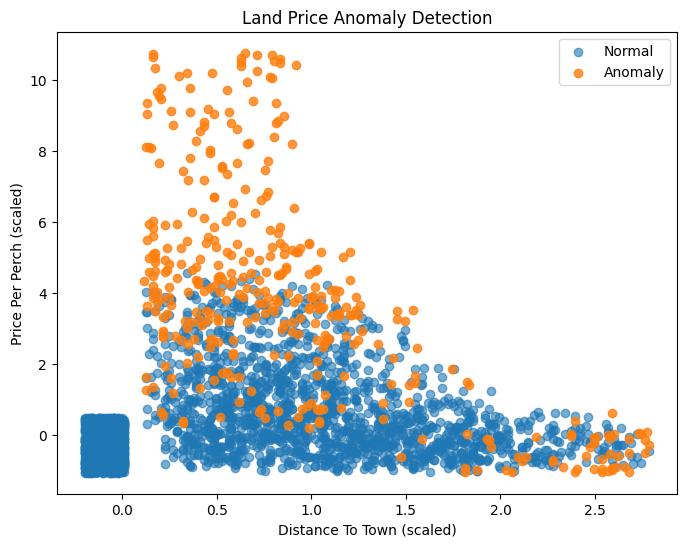

In [14]:
plt.figure(figsize=(8, 6))

normal_points = results[results["Anomaly"] == 1]
anomaly_points = results[results["Anomaly"] == -1]

plt.scatter(
    normal_points["Distance_To_Town_km"],
    normal_points["Price_Per_Perch"],
    label="Normal",
    alpha=0.6
)

plt.scatter(
    anomaly_points["Distance_To_Town_km"],
    anomaly_points["Price_Per_Perch"],
    label="Anomaly",
    alpha=0.8
)

plt.title("Land Price Anomaly Detection")
plt.xlabel("Distance To Town (scaled)")
plt.ylabel("Price Per Perch (scaled)")
plt.legend()
plt.show()

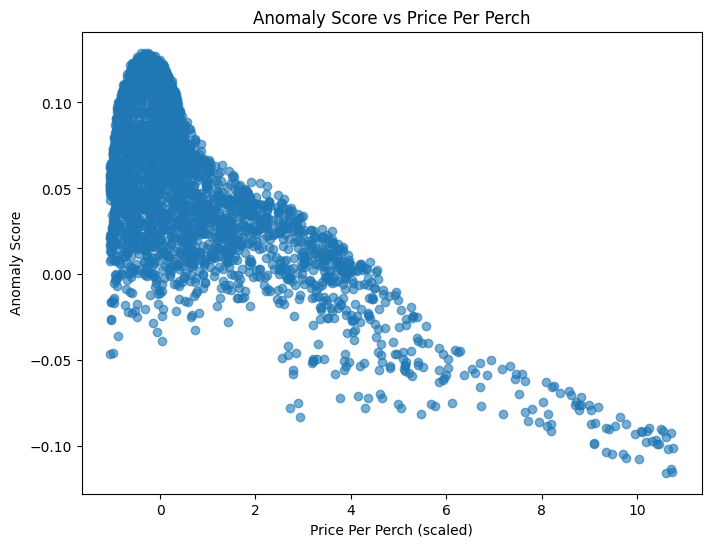

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    results["Price_Per_Perch"],
    results["Anomaly_Score"],
    alpha=0.6
)

plt.title("Anomaly Score vs Price Per Perch")
plt.xlabel("Price Per Perch (scaled)")
plt.ylabel("Anomaly Score")
plt.show()

In [16]:
anomalies = results[results["Anomaly"] == -1]
anomalies.head(10)

,Road_Access,Electricity,Water,Distance_To_Town_km,District_Mean,Land_Type_Mean,Price_Per_Perch,Price_Ratio_To_District,Anomaly,Anomaly_Score
3002,0,1,1,0.690722,9.717625,0.000000,9.402062,0.621099,-1,-0.089873
16796,0,1,0,0.144330,9.717625,3.312537,8.103093,0.333407,-1,-0.088156
6517,1,0,0,0.505155,3.908472,-1.542855,4.443299,0.858879,-1,-0.014112
16487,1,0,0,0.350515,4.610770,3.312537,4.020619,0.402992,-1,-0.026843
4058,0,0,0,0.701031,3.409643,3.312537,3.329897,0.569738,-1,-0.007580
15698,0,0,0,2.680412,-0.387883,3.312537,-1.041237,-0.902903,-1,-0.046449
10498,1,0,1,1.020619,3.409643,3.312537,3.164948,0.489636,-1,-0.008101
13124,0,1,0,0.195876,9.717625,0.000000,7.649485,0.232943,-1,-0.061941
12673,0,1,0,1.030928,3.908472,3.312537,0.752577,-0.778941,-1,-0.010655
12619,1,0,0,0.577320,9.717625,3.312537,5.061856,-0.340156,-1,-0.077843


In [17]:
joblib.dump(iso_model, "isolation_forest_model.pkl")
joblib.dump(scaler, "robust_scaler.pkl")
joblib.dump(district_mean, "district_target_map.pkl")
joblib.dump(landtype_mean, "landtype_target_map.pkl")
joblib.dump(global_price_mean, "global_price_mean.pkl")

print("Model and preprocessing objects saved successfully.")

Model and preprocessing objects saved successfully.


In [18]:
def check_price_anomaly():
    print("\nEnter Land Details\n")

    district = input("District: ").strip().title()
    land_type = input("Land Type: ").strip().title()

    road_access = input("Road Access (Yes/No): ").strip().title()
    electricity = input("Electricity (Available/Not Available): ").strip().title()
    water = input("Water (Available/Not Available): ").strip().title()

    distance_to_town_km = float(input("Distance To Town (km): "))
    price_per_perch = float(input("Price Per Perch: "))

    district_avg = district_mean.get(district, global_price_mean)
    landtype_avg = landtype_mean.get(land_type, global_price_mean)

    user_df = pd.DataFrame([{
        "Road_Access": label_map.get(road_access, 0),
        "Electricity": label_map.get(electricity, 0),
        "Water": label_map.get(water, 0),
        "Distance_To_Town_km": distance_to_town_km,
        "District_Mean": district_avg,
        "Land_Type_Mean": landtype_avg,
        "Price_Per_Perch": price_per_perch
    }])

    user_df["Price_Ratio_To_District"] = (
        user_df["Price_Per_Perch"] / (user_df["District_Mean"] + 1e-6)
    )

    user_df[columns_to_scale] = scaler.transform(user_df[columns_to_scale])

    prediction = iso_model.predict(user_df)
    score = iso_model.decision_function(user_df)

    # expected price estimate
    expected_price = (district_avg + landtype_avg) / 2

    print("\n--- Prediction Result ---")

    if prediction[0] == -1:
        if price_per_perch > expected_price:
            print("⚠️ This is a HIGH price for the given land details.")
        else:
            print("⚠️ This is a LOW price for the given land details.")
    else:
        print("✅ This is a NORMAL price for the given land details.")

    print("Entered Price :", price_per_perch)
    print("Expected Price:", round(expected_price, 2))
    print("Anomaly Score :", score[0])

In [19]:
check_price_anomaly()


Enter Land Details



District:  colombo
Land Type:  residental
Road Access (Yes/No):  yes
Electricity (Available/Not Available):  available
Water (Available/Not Available):  available
Distance To Town (km):  2
Price Per Perch:  1800000



--- Prediction Result ---
⚠️ This is a HIGH price for the given land details.
Entered Price : 1800000.0
Expected Price: 496318.07
Anomaly Score : -0.10702735945371211


In [21]:
check_price_anomaly()


Enter Land Details



District:  colombo
Land Type:  Residental
Road Access (Yes/No):  yes
Electricity (Available/Not Available):  Available
Water (Available/Not Available):  Available
Distance To Town (km):  2
Price Per Perch:  50000



--- Prediction Result ---
⚠️ This is a LOW price for the given land details.
Entered Price : 50000.0
Expected Price: 496318.07
Anomaly Score : -0.05642328801672203


In [22]:
check_price_anomaly()


Enter Land Details



District:  Gampaha
Land Type:  Residential
Road Access (Yes/No):  yes
Electricity (Available/Not Available):  Available
Water (Available/Not Available):  Available
Distance To Town (km):  5
Price Per Perch:  350000



--- Prediction Result ---
✅ This is a NORMAL price for the given land details.
Entered Price : 350000.0
Expected Price: 321415.84
Anomaly Score : 0.018918256818321932
